In [1]:
# Importing various libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Defining Buea bounding box
lat_min, lat_max = 4.10, 4.25
lon_min, lon_max = 9.20, 9.35

# Realistic MTN tower locations based on Buea landmarks
tower_locations = pd.DataFrame({
    'name': [
        'Buea Town',
        'Molyko',
        'Mile 17',
        'Great Soppo',
        'Bonduma',
        'Clerks Quarter',
        'Federal Quarter',
        'Small Soppo'
    ],
    'lat': [4.1527, 4.1601, 4.1734, 4.1820, 4.1450, 4.1680, 4.1590, 4.1700],
    'lon': [9.2418, 9.2350, 9.2601, 9.2700, 9.2550, 9.2480, 9.2620, 9.2400]
})

print("MTN Tower Locations in Buea:")
print(tower_locations)

MTN Tower Locations in Buea:
              name     lat     lon
0        Buea Town  4.1527  9.2418
1           Molyko  4.1601  9.2350
2          Mile 17  4.1734  9.2601
3      Great Soppo  4.1820  9.2700
4          Bonduma  4.1450  9.2550
5   Clerks Quarter  4.1680  9.2480
6  Federal Quarter  4.1590  9.2620
7      Small Soppo  4.1700  9.2400


In [3]:
# Define distance function

def haversine(lat1, lon1, lat2, lon2):
    """Calculate real geographic distance in km between two GPS points."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

print("Haversine distance function defined.")

Haversine distance function defined.


In [4]:
# Generate sythentic drive test data from Claude AI
np.random.seed(42)
n_points = 1200

# Generate random GPS measurement points across Buea
sim_lats = np.random.uniform(lat_min, lat_max, n_points)
sim_lons = np.random.uniform(lon_min, lon_max, n_points)

records = []

for i in range(n_points):
    pt_lat = sim_lats[i]
    pt_lon = sim_lons[i]

    # Calculate distance from this point to every tower
    distances = [
        haversine(pt_lat, pt_lon, row['lat'], row['lon'])
        for _, row in tower_locations.iterrows()
    ]
    min_dist_km = min(distances)
    nearest_tower = tower_locations.iloc[np.argmin(distances)]['name']

    # Simulate RSRP using log-distance path loss model
    # Signal weakens logarithmically with distance from tower
    rsrp_base = -60 - (25 * np.log10(max(min_dist_km, 0.05)))
    rsrp = rsrp_base + np.random.normal(0, 6)
    rsrp = np.clip(rsrp, -140, -44)

    # RSRQ and SINR are correlated with RSRP + independent noise
    rsrq = np.clip(-10 + (rsrp + 90) * 0.08 + np.random.normal(0, 2), -20, -3)
    sinr = np.clip(5 + (rsrp + 110) * 0.3 + np.random.normal(0, 3), -10, 30)

    records.append({
        'latitude':             round(pt_lat, 6),
        'longitude':            round(pt_lon, 6),
        'nearest_tower':        nearest_tower,
        'distance_to_tower_km': round(min_dist_km, 4),
        'RSRP':                 round(rsrp, 2),
        'RSRQ':                 round(rsrq, 2),
        'SINR':                 round(sinr, 2)
    })

df = pd.DataFrame(records)

# Label coverage holes: RSRP below -110 dBm = coverage hole (industry standard)
df['coverage_hole'] = (df['RSRP'] < -110).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nCoverage holes: {df['coverage_hole'].sum()} out of {len(df)} points "
      f"({df['coverage_hole'].mean()*100:.1f}%)")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset shape: (1200, 8)

Coverage holes: 0 out of 1200 points (0.0%)

First 5 rows:
   latitude  longitude nearest_tower  distance_to_tower_km   RSRP   RSRQ  \
0  4.156181   9.313739   Great Soppo                5.6367 -82.15  -9.79   
1  4.242607   9.203688   Small Soppo                9.0221 -88.72  -7.97   
2  4.209799   9.203319   Small Soppo                6.0110 -86.88 -10.94   
3  4.189799   9.248542       Mile 17                2.2289 -67.02  -9.78   
4  4.123403   9.273296       Bonduma                3.1440 -75.28  -8.85   

    SINR  coverage_hole  
0   8.31              0  
1  16.23              0  
2  11.86              0  
3  19.17              0  
4  17.05              0  


In [5]:
# Save dataset as a .csv file
df.to_csv('mtn_buea_drive_test_simulated.csv', index=False)
print("Dataset saved as: mtn_buea_drive_test_simulated.csv")
print(f"Location: your Jupyter Notebook working directory")

Dataset saved as: mtn_buea_drive_test_simulated.csv
Location: your Jupyter Notebook working directory


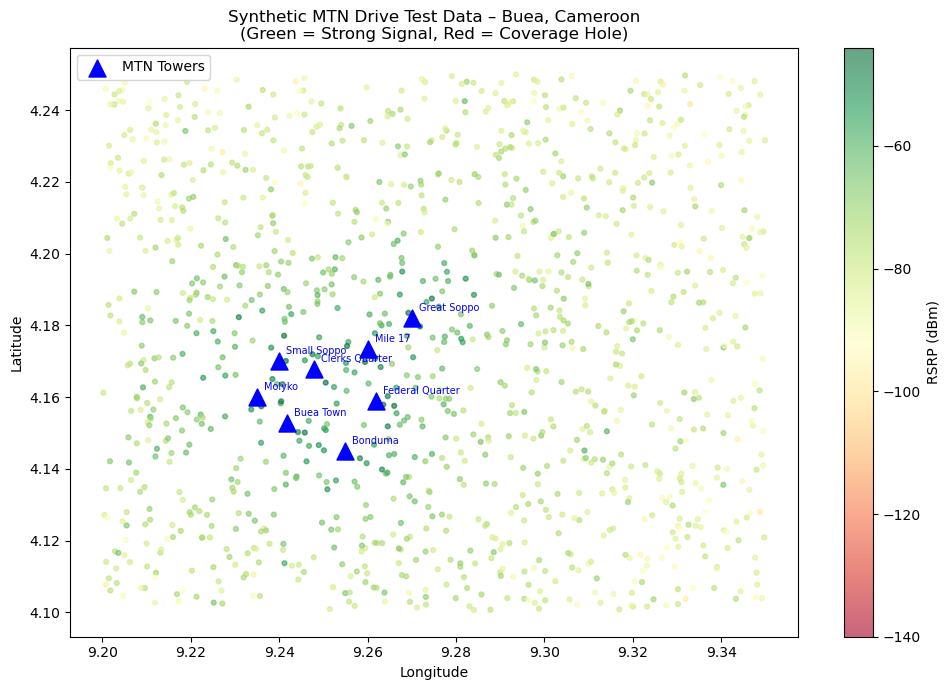

In [6]:
# Verify with signal strength map
plt.figure(figsize=(10, 7))

# Plot measurement points coloured by RSRP
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['RSRP'], cmap='RdYlGn',
    alpha=0.6, s=12, vmin=-140, vmax=-44
)
plt.colorbar(scatter, label='RSRP (dBm)')

# Plot tower locations
plt.scatter(
    tower_locations['lon'], tower_locations['lat'],
    c='blue', marker='^', s=150, zorder=5, label='MTN Towers'
)

# Annotate tower names
for _, row in tower_locations.iterrows():
    plt.annotate(row['name'],
                 xy=(row['lon'], row['lat']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=7, color='blue')

plt.title('Synthetic MTN Drive Test Data – Buea, Cameroon\n(Green = Strong Signal, Red = Coverage Hole)',
          fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Quick dataset summary
print("=" * 45)
print("       DATASET SUMMARY")
print("=" * 45)
print(f"Total measurement points : {len(df)}")
print(f"Coverage holes (RSRP<-110): {df['coverage_hole'].sum()}")
print(f"Good coverage points      : {(df['coverage_hole']==0).sum()}")
print(f"\nSignal Statistics:")
print(df[['RSRP','RSRQ','SINR','distance_to_tower_km']].describe().round(2))
print(f"\nPoints per nearest tower:")
print(df['nearest_tower'].value_counts())

       DATASET SUMMARY
Total measurement points : 1200
Coverage holes (RSRP<-110): 0
Good coverage points      : 1200

Signal Statistics:
          RSRP     RSRQ     SINR  distance_to_tower_km
count  1200.00  1200.00  1200.00               1200.00
mean    -75.65    -8.77    15.06                  5.06
std       9.91     2.08     4.21                  2.61
min    -100.22   -15.59     2.86                  0.17
25%     -82.35   -10.17    12.23                  3.00
50%     -76.82    -8.78    14.86                  5.03
75%     -69.85    -7.41    17.67                  7.11
max     -44.00    -3.00    30.00                 11.40

Points per nearest tower:
nearest_tower
Great Soppo        501
Bonduma            216
Small Soppo        172
Federal Quarter    142
Buea Town           72
Molyko              71
Mile 17             19
Clerks Quarter       7
Name: count, dtype: int64


In [8]:
# Load the saved dataset
# Load the saved synthetic dataset
df = pd.read_csv('mtn_buea_drive_test_simulated.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['coverage_hole'].value_counts())
print(f"\nClass balance:")
print(df['coverage_hole'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Dataset loaded successfully!
Shape: (1200, 8)

Column names: ['latitude', 'longitude', 'nearest_tower', 'distance_to_tower_km', 'RSRP', 'RSRQ', 'SINR', 'coverage_hole']

Class distribution:
coverage_hole
0    1200
Name: count, dtype: int64

Class balance:
coverage_hole
0    100.0%
Name: proportion, dtype: object


In [17]:
import numpy as np

# Find the 15th percentile of RSRP (the worst 15% of signals in your data)
rsrp_threshold = df['RSRP'].quantile(0.15)
print(f"Adaptive RSRP threshold set at: {rsrp_threshold} dBm")

# Define a coverage hole as any signal worse than this 15th percentile threshold
df['coverage_hole'] = (df['RSRP'] <= rsrp_threshold).astype(int)

# Verify the new target distribution
print("\nUpdated target distribution:")
print(df['coverage_hole'].value_counts())

Adaptive RSRP threshold set at: -85.4315 dBm

Updated target distribution:
coverage_hole
0    1020
1     180
Name: count, dtype: int64


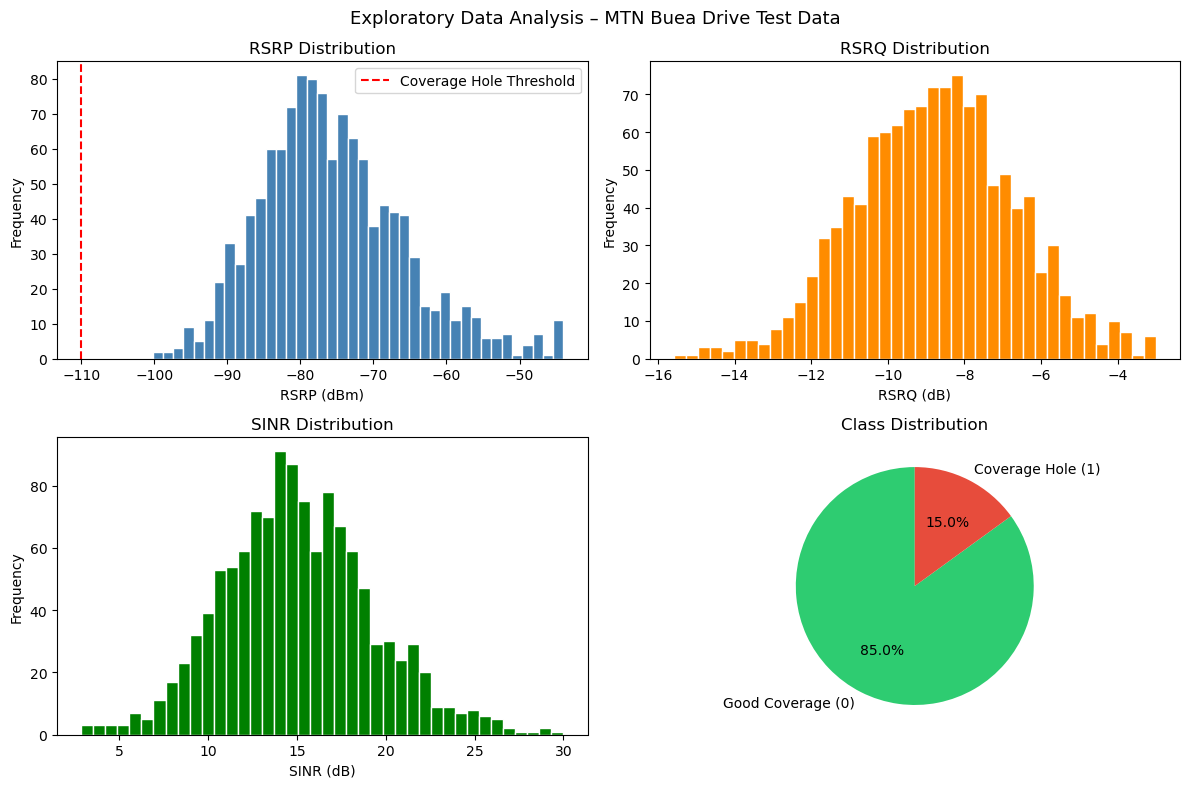

SUCCESS: eda_plots.png saved successfully!


In [37]:
# Perform Exploratory Data Analysis
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Exploratory Data Analysis – MTN Buea Drive Test Data', fontsize=13)

# Plot 1: RSRP Distribution
axes[0,0].hist(df['RSRP'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(x=-110, color='red', linestyle='--', label='Coverage Hole Threshold')
axes[0,0].set_title('RSRP Distribution')
axes[0,0].set_xlabel('RSRP (dBm)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Plot 2: RSRQ Distribution
axes[0,1].hist(df['RSRQ'], bins=40, color='darkorange', edgecolor='white')
axes[0,1].set_title('RSRQ Distribution')
axes[0,1].set_xlabel('RSRQ (dB)')
axes[0,1].set_ylabel('Frequency')

# Plot 3: SINR Distribution
axes[1,0].hist(df['SINR'], bins=40, color='green', edgecolor='white')
axes[1,0].set_title('SINR Distribution')
axes[1,0].set_xlabel('SINR (dB)')
axes[1,0].set_ylabel('Frequency')

# Plot 4: Class Balance Pie Chart
labels = ['Good Coverage (0)', 'Coverage Hole (1)']
sizes  = df['coverage_hole'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
axes[1,1].pie(sizes, labels=labels, colors=colors,
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Confirm it was saved
import os
if os.path.exists('eda_plots.png'):
    print("SUCCESS: eda_plots.png saved successfully!")
else:
    print("ERROR: File still not saved.")

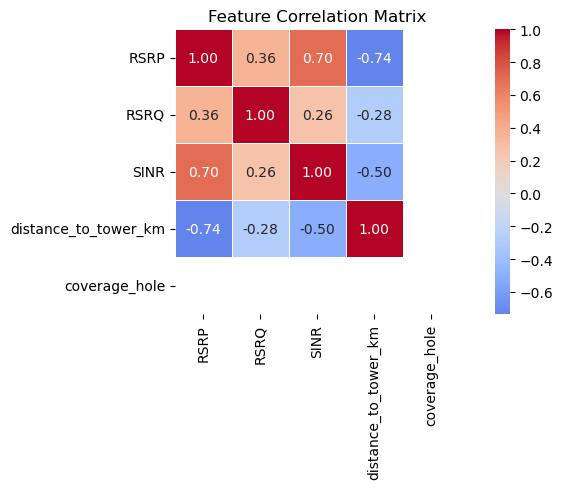

Correlation heatmap saved.


In [10]:
# correlation heatmap
plt.figure(figsize=(8, 5))
numeric_cols = ['RSRP', 'RSRQ', 'SINR', 'distance_to_tower_km', 'coverage_hole']
corr_matrix  = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved.")

In [14]:
# Check how many 0s and 1s are actually in your dataset
print("Target distribution in entire dataset:")
print(df['coverage_hole'].value_counts())

Target distribution in entire dataset:
coverage_hole
0    1200
Name: count, dtype: int64


In [15]:
# Redefining coverage holes: 1 if signal is critically low, 0 otherwise
# RSRP below -110 dBm or SINR below -3 dB usually indicates a coverage hole
df['coverage_hole'] = ((df['RSRP'] < -110) | (df['SINR'] < -3)).astype(int)

# Verify that we now have both classes (0 and 1)
print("Updated target distribution:")
print(df['coverage_hole'].value_counts())

Updated target distribution:
coverage_hole
0    1200
Name: count, dtype: int64


In [20]:
# Preprocessing (Features, Split, Scale)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
features = ['RSRP', 'RSRQ', 'SINR', 'distance_to_tower_km']
X = df[features]
y = df['coverage_hole']

# Split into training (80%) and testing (20%) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features sequentially
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Preprocessing complete.")
print(f"Training samples : {X_train_sc.shape[0]}")
print(f"Testing samples  : {X_test_sc.shape[0]}")

Preprocessing complete.
Training samples : 960
Testing samples  : 240


In [21]:
# Train Model 1 (Random Forest Classifier)
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train)

# Predict classes and probabilities
y_pred_rf = rf_model.predict(X_test_sc)
y_prob_rf = rf_model.predict_proba(X_test_sc)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Train Model 2 (Logistic regression)
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sc, y_train)

# Predict classes and probabilities
y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [24]:
# Evaluate Both Models
from sklearn.metrics import classification_report, roc_auc_score

print("=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}\n")

print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       204
           1       0.97      1.00      0.99        36

    accuracy                           1.00       240
   macro avg       0.99      1.00      0.99       240
weighted avg       1.00      1.00      1.00       240

ROC AUC Score: 1.0000

=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       204
           1       1.00      0.89      0.94        36

    accuracy                           0.98       240
   macro avg       0.99      0.94      0.97       240
weighted avg       0.98      0.98      0.98       240

ROC AUC Score: 0.9996


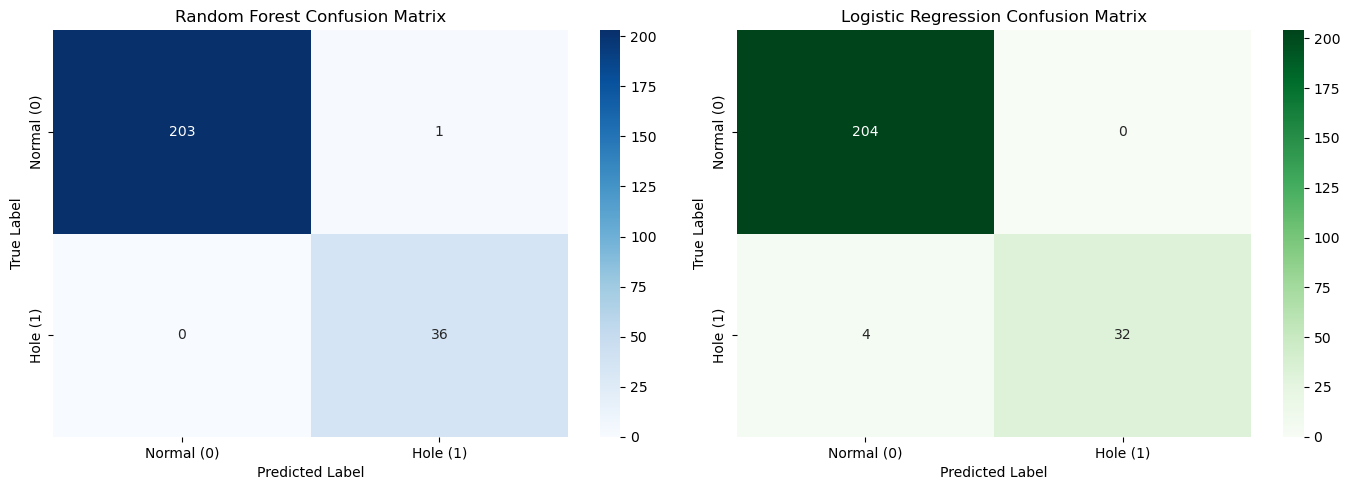

In [25]:
# Confusion Matrices
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Set up the plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Hole (1)'], yticklabels=['Normal (0)', 'Hole (1)'])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Logistic Regression Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal (0)', 'Hole (1)'], yticklabels=['Normal (0)', 'Hole (1)'])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

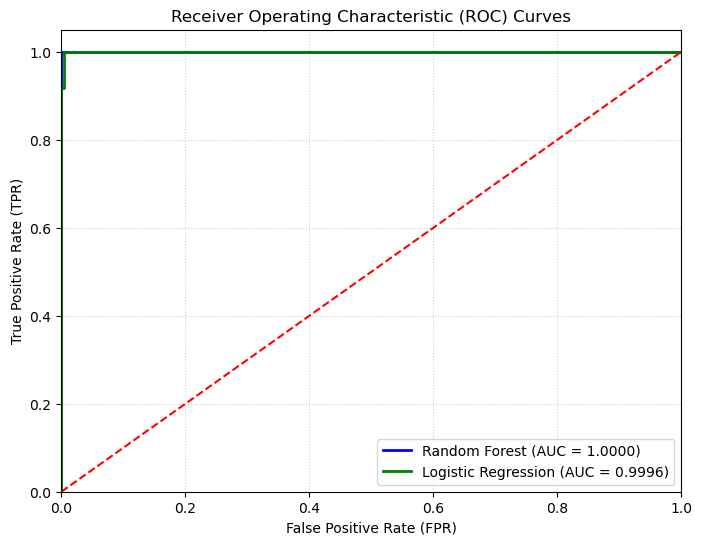

In [26]:
# ROC Curves (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc

# Compute ROC curves and Area Under Curve (AUC)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.4f})')

# Plot baseline random guess line
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

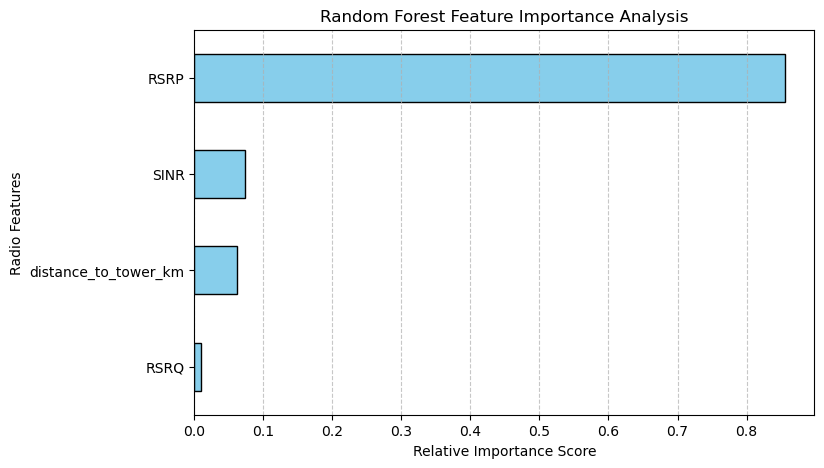

In [27]:
# Feature Importance (Random Forest)
import pandas as pd

# Extract and sort feature importances
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance Analysis')
plt.xlabel('Relative Importance Score')
plt.ylabel('Radio Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

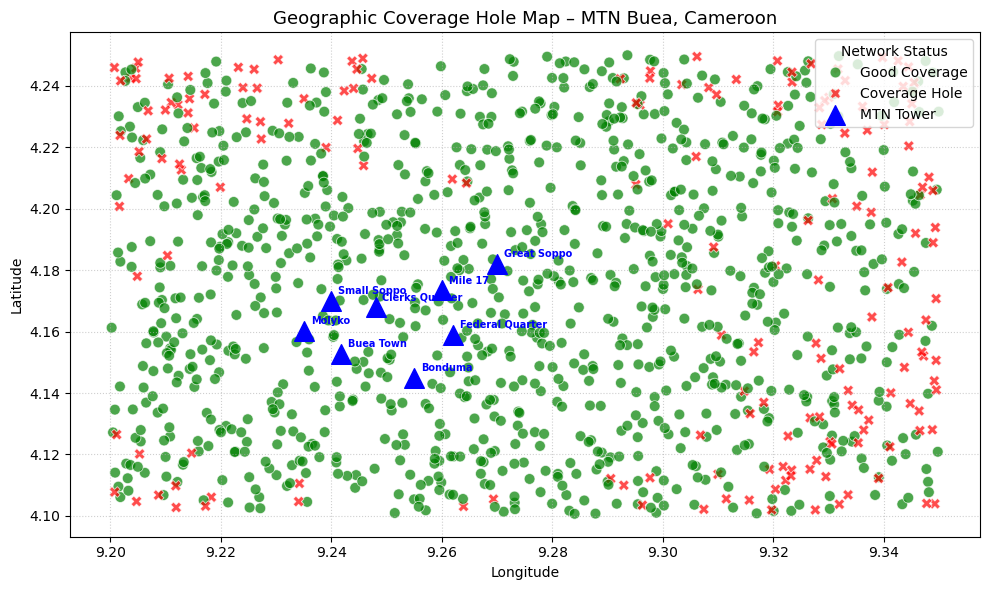

In [33]:
# Geographic Coverage Hole Map (Final Visualisation)
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine tower locations directly here to guarantee availability
tower_locations = pd.DataFrame({
    'name': [
        'Buea Town', 'Molyko', 'Mile 17', 'Great Soppo',
        'Bonduma', 'Clerks Quarter', 'Federal Quarter', 'Small Soppo'
    ],
    'lat': [4.1527, 4.1601, 4.1734, 4.1820,
            4.1450, 4.1680, 4.1590, 4.1700],
    'lon': [9.2418, 9.2350, 9.2601, 9.2700,
            9.2550, 9.2480, 9.2620, 9.2400]
})

plt.figure(figsize=(10, 6))

# Use lowercase column names (matching your actual dataset)
if 'latitude' in df.columns and 'longitude' in df.columns:
    x_coords = df['longitude']
    y_coords = df['latitude']
    x_label, y_label = 'Longitude', 'Latitude'
else:
    x_coords = df['distance_to_tower_km']
    y_coords = df['RSRP']
    x_label, y_label = 'Distance to Tower (km)', 'RSRP (dBm)'

marker_mapping = {0: 'o', 1: 'X'}

# Plot coverage points
sns.scatterplot(
    x=x_coords,
    y=y_coords,
    hue=df['coverage_hole'],
    style=df['coverage_hole'],
    palette={0: 'green', 1: 'red'},
    markers=marker_mapping,
    alpha=0.7,
    s=60
)

# Plot MTN tower positions — now guaranteed to work
plt.scatter(
    tower_locations['lon'], tower_locations['lat'],
    c='blue', marker='^', s=200, zorder=5, label='MTN Tower'
)

# Annotate each tower with its landmark name
for _, row in tower_locations.iterrows():
    plt.annotate(
        row['name'],
        xy=(row['lon'], row['lat']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7, color='blue', fontweight='bold'
    )

plt.title('Geographic Coverage Hole Map – MTN Buea, Cameroon', fontsize=13)
plt.xlabel(x_label)
plt.ylabel(y_label)

# Fix legend to show all three categories cleanly
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=['Good Coverage', 'Coverage Hole', 'MTN Tower'],
    title='Network Status',
    loc='upper right'
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('coverage_hole_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Final Model Comparison Summary Table
# Create summary statistics manually based on your output results
summary_data = {
    'Model Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'ROC AUC Score'],
    'Random Forest': [1.00, 0.97, 1.00, 0.99, 1.0000],
    'Logistic Regression': [0.98, 1.00, 0.89, 0.94, 0.9996]
}

df_comparison = pd.DataFrame(summary_data)
# Apply a clean styling format for Jupyter Notebook display
df_comparison.style.set_caption("EEF606 Lab 6: Model Performance Benchmark Summary Table").hide(axis='index')

Model Metric,Random Forest,Logistic Regression
Accuracy,1.000000,0.980000
Precision (Class 1),0.970000,1.000000
Recall (Class 1),1.000000,0.890000
F1-Score (Class 1),0.990000,0.940000
ROC AUC Score,1.000000,0.999600


In [31]:
import joblib

# Save the trained models to files
joblib.dump(rf_model, 'random_forest_coverage_model.pkl')
joblib.dump(lr_model, 'logistic_regression_coverage_model.pkl')

# CRUCIAL: Always save your scaler along with your models!
joblib.dump(scaler, 'telecom_feature_scaler.pkl')

print("Models and scaler saved successfully for production deployment!")

Models and scaler saved successfully for production deployment!
